In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from string import ascii_lowercase, ascii_uppercase


In [2]:
plt.rcParams.update({"font.size": 18})

In [15]:
link = 'https://ozonewatch.gsfc.nasa.gov/meteorology/figures/merra2/wind/u60n_10_2024_merra2.txt'
df = pd.read_csv(link, skiprows=6, delim_whitespace=True)
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df

/tmp/ipykernel_439000/2665348507.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(link, skiprows=6, delim_whitespace=True)


,Data,Minimum,10%,30%,Mean,70%,90%,Maximum
Date,,,,,,,,
2024-07-01,-11.08,-13.76,-13.21,-12.68,-12.07,-11.60,-11.13,-10.28
2024-07-02,-10.76,-13.97,-12.93,-12.44,-12.02,-11.70,-10.84,-10.21
2024-07-03,-11.24,-13.91,-12.79,-12.36,-11.90,-11.43,-10.89,-9.80
2024-07-04,-11.57,-14.28,-13.07,-12.51,-11.97,-11.40,-10.91,-9.51
2024-07-05,-11.60,-13.98,-13.21,-12.43,-11.94,-11.45,-10.86,-9.56
...,...,...,...,...,...,...,...,...
2025-06-26,-9.36,-14.13,-13.30,-12.54,-11.99,-11.38,-10.83,-9.36
2025-06-27,-10.01,-14.27,-13.37,-12.41,-12.00,-11.49,-10.82,-10.01
2025-06-28,-10.08,-14.63,-13.39,-12.61,-12.02,-11.41,-10.76,-10.08


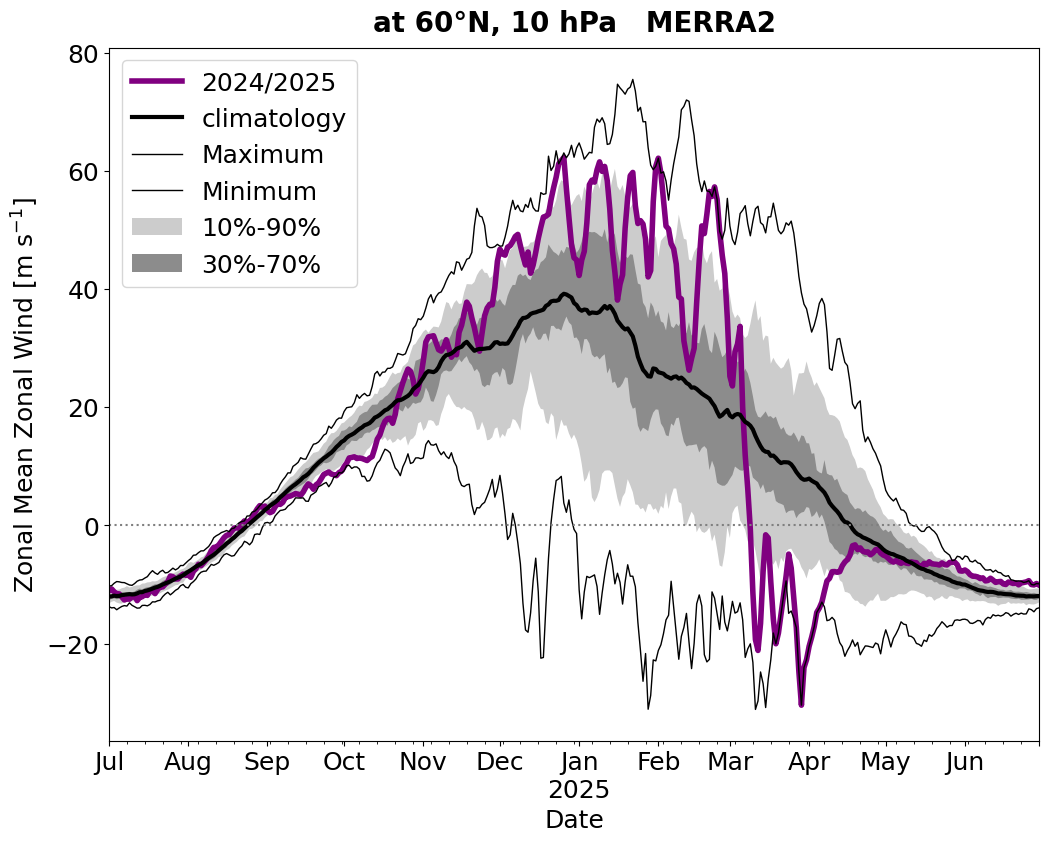

In [5]:
fig, ax = plt.subplots(figsize= (12,9))
x = mdates.date2num(df.index.to_pydatetime())
df['Data'].plot(color = 'purple', ax = ax, lw = 4, label = '2024/2025')
df['Mean'].plot(color = 'k', ax = ax, lw = 3, label = 'climatology')
df['Maximum'].plot(color = 'k', ax = ax, lw = 1)
df['Minimum'].plot(color = 'k', ax = ax, lw = 1)

ax.fill_between(x, df["10%"].to_numpy(), df["90%"].to_numpy(), color="0.80", edgecolor="none", label = '10%-90%')
ax.fill_between(x, df["30%"].to_numpy(), df["70%"].to_numpy(), color="0.55", edgecolor="none", label='30%-70%')

ax.legend()

ax.axhline(0, ls = 'dotted', c = 'gray')
ax.set_ylabel(r"Zonal Mean Zonal Wind [m s$^{-1}$]", fontsize=18)
ax.set_title("at 60°N, 10 hPa   MERRA2", fontsize=20, weight="bold", pad=12)

outfile = 'Fig1A_ZW6010_MERRA2.pdf'
plt.savefig(outfile,  bbox_inches='tight')

In [6]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

False

In [7]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

In [14]:
link = 'https://ozonewatch.gsfc.nasa.gov/meteorology/figures/merra2/heat_flux/vt45_75-45n_100_2024_merra2.txt'
df2 = pd.read_csv(link, skiprows=6, delim_whitespace=True)
df2["Date"] = pd.to_datetime(df2["Date"])
df2 = df2.set_index("Date").sort_index()
df2

/tmp/ipykernel_439000/1411425527.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv(link, skiprows=6, delim_whitespace=True)


,Data,Minimum,10%,30%,Mean,70%,90%,Maximum
Date,,,,,,,,
2024-07-01,2.79,1.74,2.13,2.44,2.64,2.84,3.07,3.66
2024-07-02,2.79,1.69,2.12,2.42,2.60,2.80,2.95,3.58
2024-07-03,2.76,1.67,2.08,2.40,2.56,2.74,2.89,3.51
2024-07-04,2.72,1.67,2.07,2.35,2.53,2.72,2.86,3.45
2024-07-05,2.71,1.68,2.08,2.31,2.50,2.68,2.83,3.37
...,...,...,...,...,...,...,...,...
2025-06-26,2.60,1.89,2.32,2.67,2.90,3.09,3.47,4.46
2025-06-27,2.60,1.90,2.27,2.61,2.84,3.03,3.40,4.27
2025-06-28,2.61,1.88,2.22,2.60,2.79,2.97,3.31,4.01


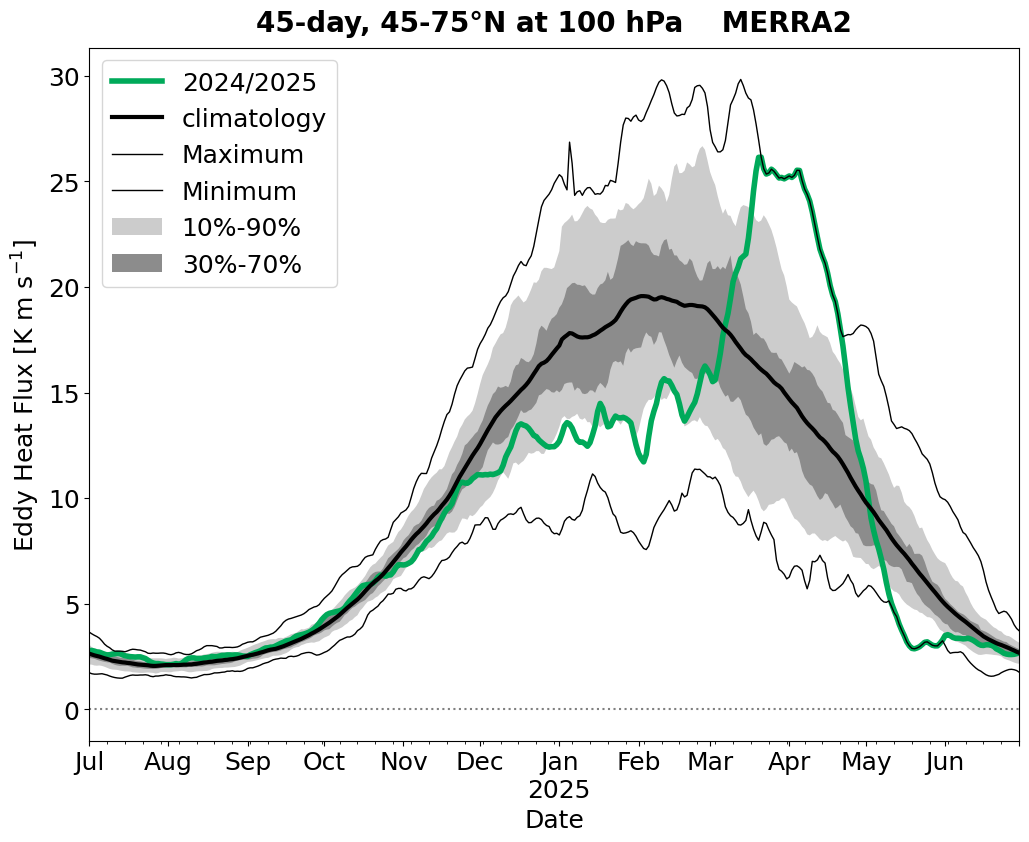

In [12]:
fig, ax = plt.subplots(figsize= (12,9))
x = mdates.date2num(df.index.to_pydatetime())
df['Data'].plot(color = '#00aa5a', ax = ax, lw = 4, label = '2024/2025')
df['Mean'].plot(color = 'k', ax = ax, lw = 3, label = 'climatology')
df['Maximum'].plot(color = 'k', ax = ax, lw = 1)
df['Minimum'].plot(color = 'k', ax = ax, lw = 1)

ax.fill_between(x, df["10%"].to_numpy(), df["90%"].to_numpy(), color="0.80", edgecolor="none", label = '10%-90%')
ax.fill_between(x, df["30%"].to_numpy(), df["70%"].to_numpy(), color="0.55", edgecolor="none", label='30%-70%')

ax.legend()

ax.axhline(0, ls = 'dotted', c = 'gray')
ax.set_ylabel(r"Eddy Heat Flux [K m s$^{-1}$]", fontsize=18)
ax.set_title("45-day, 45-75°N at 100 hPa    MERRA2", fontsize=20, weight="bold", pad=12)

outfile = 'Fig1B_EHF100hPa_MERRA2.pdf'
plt.savefig(outfile,  bbox_inches='tight')

In [13]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

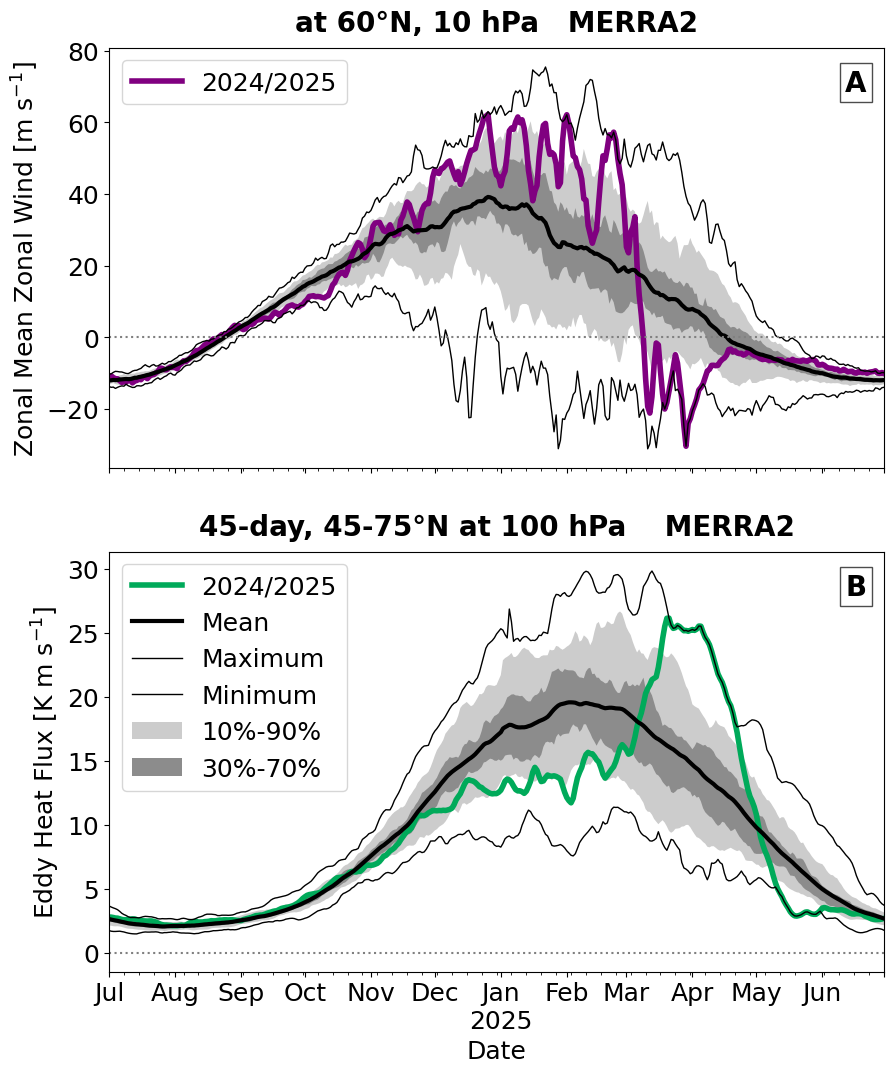

In [38]:
fig, axes = plt.subplots(nrows = 2, figsize= (10,12), sharex=True)

ax = axes[0]
x = mdates.date2num(df.index.to_pydatetime())
df['Data'].plot(color = 'purple', ax = ax, lw = 4, label = '2024/2025')
df['Mean'].plot(color = 'k', ax = ax, lw = 3, label = '')
df['Maximum'].plot(color = 'k', ax = ax, lw = 1, label = '')
df['Minimum'].plot(color = 'k', ax = ax, lw = 1, label = '')

ax.fill_between(x, df["10%"].to_numpy(), df["90%"].to_numpy(), color="0.80", edgecolor="none", label = '')
ax.fill_between(x, df["30%"].to_numpy(), df["70%"].to_numpy(), color="0.55", edgecolor="none", label='')

ax.legend(loc ='upper left')

ax.axhline(0, ls = 'dotted', c = 'gray')
ax.set_ylabel(r"Zonal Mean Zonal Wind [m s$^{-1}$]", fontsize=18)
ax.set_title("at 60°N, 10 hPa   MERRA2", fontsize=20, weight="bold", pad=12)

ax = axes[1]

x = mdates.date2num(df2.index.to_pydatetime())
df2['Data'].plot(color = '#00aa5a', ax = ax, lw = 4, label = '2024/2025')
df2['Mean'].plot(color = 'k', ax = ax, lw = 3, label = 'Mean')
df2['Maximum'].plot(color = 'k', ax = ax, lw = 1)
df2['Minimum'].plot(color = 'k', ax = ax, lw = 1)

ax.fill_between(x, df2["10%"].to_numpy(), df2["90%"].to_numpy(), color="0.80", edgecolor="none", label = '10%-90%')
ax.fill_between(x, df2["30%"].to_numpy(), df2["70%"].to_numpy(), color="0.55", edgecolor="none", label='30%-70%')

ax.legend()

ax.axhline(0, ls = 'dotted', c = 'gray')
ax.set_ylabel(r"Eddy Heat Flux [K m s$^{-1}$]", fontsize=18)
ax.set_title("45-day, 45-75°N at 100 hPa    MERRA2", fontsize=20, weight="bold", pad=12)

for i,ax in enumerate(axes):
    label = ascii_uppercase[i]
    ax.text(
            0.95,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )

    

outfile = 'Fig1_ZW+EHF_MERRA2.pdf'
plt.savefig(outfile,  bbox_inches='tight')

In [40]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)